<p style ="text-align:center">
    <img src="https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# SAOP09 - Data Science For Business
## Prof. Eduardo Pécora


# Train-Test-Split
Tempo estimado: **30** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Entender por que precisamos separar os dados em treino e teste **antes** de treinar o modelo
* Aplicar `train_test_split` de forma que a comparação entre modelos seja justa
* Entender o que acontece quando um modelo tem mais variáveis do que observações de treino

## Bibliotecas

In [8]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd

# Importando numpy para operações matemáticas
import numpy as np

# importando as bibliotecas do matplotlib e seaborn para gerar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Classe de regressão
from sklearn.linear_model import LinearRegression

# Ferramenta desta aula: divisão dos dados em treino e teste
from sklearn.model_selection import train_test_split

%matplotlib inline

## Obtendo dados

In [9]:
# Caminho do arquivo csv
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/MeuAutoLimpo.csv"

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho)

## Retomando o exemplo da aula passada

Na aula sobre o problema do $R^2$ comparamos dois modelos nos **mesmos dados usados para treinar**:

* um modelo **honesto**, com 15 variáveis reais;
* um modelo **inflado**, com essas mesmas 15 variáveis reais + 150 colunas de puro ruído aleatório.

O modelo inflado teve um $R^2$ maior e resíduos visualmente melhores — mas isso não prova nada sobre a qualidade real do modelo, porque ele foi avaliado exatamente nos dados que já tinha visto durante o treino.

Vamos recriar os dois modelos para fazer, desta vez, uma **comparação justa**.

In [10]:
# Removendo as variáveis categóricas (mantém apenas colunas numéricas)
df_linear_multipla = df.select_dtypes(exclude='object')

df_linear_multipla.shape

(201, 16)

In [11]:
# Recriando as 150 colunas de ruído aleatório (mesmo procedimento da aula anterior)
c = 150
colunas_aleatorias = pd.DataFrame(
    np.random.randint(1, 100, size=(len(df_linear_multipla), c)),
    columns=[f'Random_{i+1}' for i in range(c)],
    index=df_linear_multipla.index
)
df_inflado = pd.concat([df_linear_multipla, colunas_aleatorias], axis=1)

# Guardando os nomes das variáveis reais, para conseguir isolá-las depois da divisão
colunas_reais = df_linear_multipla.drop(columns=['price']).columns

df_inflado.shape

(201, 166)

## Uma comparação justa

Para que a comparação seja justa, os dois modelos (honesto e inflado) precisam:

1. ser avaliados nas **mesmas linhas** de teste;
2. e, principalmente, **nunca ter visto essas linhas durante o treino**.

Por isso, fazemos a divisão treino/teste **uma única vez**, sobre o dataset completo (com as colunas aleatórias), e depois isolamos as variáveis reais dentro dessa mesma divisão. Assim garantimos que as mesmas linhas vão para treino e para teste nos dois modelos.

In [12]:
X_completo = df_inflado.drop(columns=['price'])
Y_completo = df_inflado['price']

# Uma única divisão treino/teste para os dois modelos
X_train_completo, X_test_completo, y_train, y_test = train_test_split(
    X_completo, Y_completo, test_size=0.20, random_state=42
)

# O modelo honesto usa só as colunas reais dessa mesma divisão
X_train_honesto = X_train_completo[colunas_reais]
X_test_honesto = X_test_completo[colunas_reais]

lm_honesto = LinearRegression().fit(X_train_honesto, y_train)
lm_inflado = LinearRegression().fit(X_train_completo, y_train)

print(f"Linhas de treino: {len(X_train_completo)}  |  Linhas de teste: {len(X_test_completo)}")
print(f"Variáveis do modelo honesto: {X_train_honesto.shape[1]}  |  Variáveis do modelo inflado: {X_train_completo.shape[1]}")
print()
print(f"Honesto  ->  SCORE treino: {lm_honesto.score(X_train_honesto, y_train):.4f}   SCORE teste: {lm_honesto.score(X_test_honesto, y_test):.4f}")
print(f"Inflado  ->  SCORE treino: {lm_inflado.score(X_train_completo, y_train):.4f}   SCORE teste: {lm_inflado.score(X_test_completo, y_test):.4f}")

Linhas de treino: 160  |  Linhas de teste: 41
Variáveis do modelo honesto: 15  |  Variáveis do modelo inflado: 165

Honesto  ->  SCORE treino: 0.8523   SCORE teste: 0.7900
Inflado  ->  SCORE treino: 1.0000   SCORE teste: -3.8567


### Por que o $R^2$ pode ser negativo?

Apesar do nome sugerir "R ao quadrado", o $R^2$ que o `.score()` do scikit-learn calcula **não é literalmente o quadrado de nada**. Ele é definido como:

$$
R^2 = 1 - \dfrac{SS_{res}}{SS_{tot}}
$$

onde $SS_{res}$ é a soma dos quadrados dos resíduos (o erro do modelo) e $SS_{tot}$ é a soma dos quadrados dos desvios em relação à média (o erro que teríamos só "chutando" a média do preço para todo mundo).

Quando o modelo generaliza bem, $SS_{res}$ é bem menor que $SS_{tot}$, e o $R^2$ fica perto de 1. Mas quando o modelo generaliza mal — como o modelo inflado neste exemplo — o erro dele em dados novos pode ficar **maior** do que simplesmente prever a média para todo mundo. Nesse caso $SS_{res} > SS_{tot}$, a fração fica maior que 1, e o resultado de $1 - \dfrac{SS_{res}}{SS_{tot}}$ vira negativo.

Um $R^2$ negativo não é um erro de cálculo — é o scikit-learn avisando que o modelo está pior do que simplesmente chutar a média.

### Mais variáveis do que observações de treino

Repare que o modelo inflado tem mais variáveis do que linhas de treino. Nesse cenário, o modelo tem "graus de liberdade" de sobra para se ajustar **perfeitamente** aos dados de treino — inclusive ao ruído das colunas aleatórias — o que costuma produzir um $R^2$ de treino próximo de 1. O preço disso aparece no conjunto de teste: como o modelo memorizou padrões que não existem de verdade, as previsões para dados novos podem ficar muito piores do que as de um modelo bem mais simples.

### Visualizando a comparação

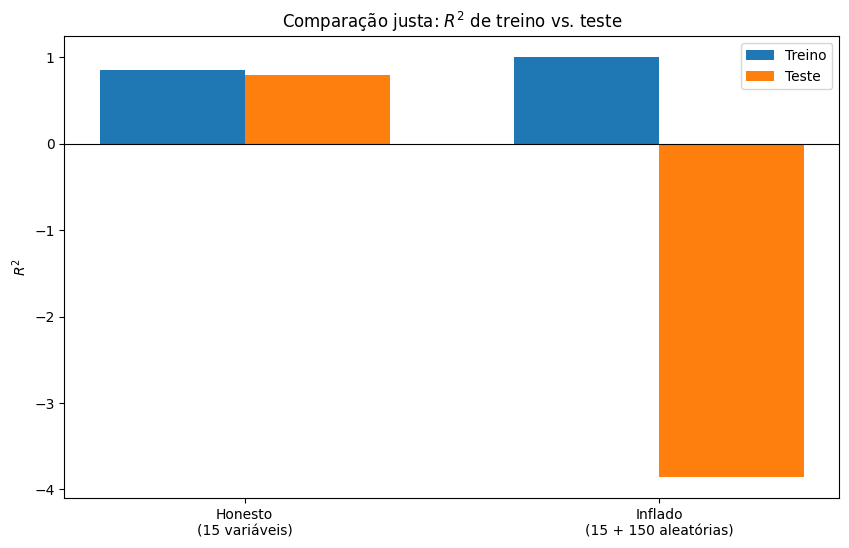

In [13]:
modelos = ['Honesto\n(15 variáveis)', f'Inflado\n(15 + {c} aleatórias)']
r2_treino = [lm_honesto.score(X_train_honesto, y_train), lm_inflado.score(X_train_completo, y_train)]
r2_teste  = [lm_honesto.score(X_test_honesto, y_test), lm_inflado.score(X_test_completo, y_test)]

x = np.arange(len(modelos))
largura = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - largura/2, r2_treino, largura, label='Treino')
plt.bar(x + largura/2, r2_teste, largura, label='Teste')
plt.axhline(0, color='k', linewidth=0.8)
plt.xticks(x, modelos)
plt.ylabel('$R^2$')
plt.title('Comparação justa: $R^2$ de treino vs. teste')
plt.legend()
plt.show()

### Resíduos no conjunto de teste

Na aula passada comparamos os resíduos dos dois modelos nos dados de **treino**, e o modelo inflado parecia muito melhor. Vamos repetir essa comparação agora, mas usando o conjunto de **teste** — dados que nenhum dos dois modelos viu durante o treino.

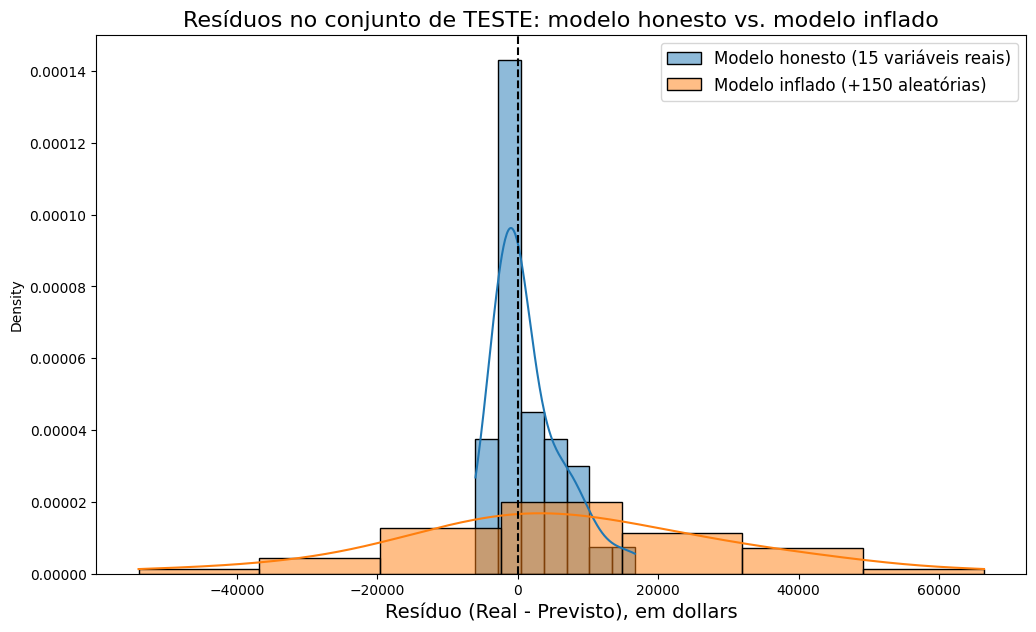

In [14]:
residuos_honesto_teste = y_test - lm_honesto.predict(X_test_honesto)
residuos_inflado_teste = y_test - lm_inflado.predict(X_test_completo)

plt.figure(figsize=(12, 7))

sns.histplot(residuos_honesto_teste, kde=True, stat="density", color="tab:blue",
             label="Modelo honesto (15 variáveis reais)", alpha=0.5)
sns.histplot(residuos_inflado_teste, kde=True, stat="density", color="tab:orange",
             label=f"Modelo inflado (+{c} aleatórias)", alpha=0.5)

plt.axvline(0, color="k", linestyle="--")
plt.title("Resíduos no conjunto de TESTE: modelo honesto vs. modelo inflado", size=16)
plt.xlabel("Resíduo (Real - Previsto), em dollars", size=14)
plt.legend(fontsize=12)
plt.show()

### A ilusão desfeita

Nos dados de treino, o modelo inflado parecia claramente superior. No conjunto de teste, essa vantagem desaparece — e pode até se inverter. O $R^2$ de treino de um modelo nunca vai te dizer isso sozinho: ele só mede o quanto o modelo se ajustou aos dados que ele já viu.

É por isso que **nunca avaliamos um modelo nos mesmos dados usados para treiná-lo**. Separar treino e teste antes de treinar é o que garante uma comparação justa entre modelos — simples ou complexos.

### Próxima aula

Agora que sabemos avaliar modelos de forma justa, vamos aprender a incorporar variáveis categóricas (como a marca ou o número de portas de um carro) nos nossos modelos de regressão.

## Fique Conectado

- [![YouTube](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/youtube_icon_color.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/linkedin_icon_color.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/instagram_icon_color.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Referências:

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação da biblioteca <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html">Scikit-learn (train_test_split)</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 01-09-2026       | 1.0     | Claude (a pedido de Eduardo Pécora) | Criação - NB4 passa a ser o Train-Test-Split, construído a partir do exemplo honesto vs. inflado do NB3 |